In [18]:

import cv2
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

In [19]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

feature_extractor = Model(inputs=base_model.input, outputs=x)

print("Feature extractor ready!")

Feature extractor ready!


In [40]:
data = []
labels = []

dataset_path = r"C:\dataset"

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):

        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path)

        # 🔴 Important fix
        if img is None:
            print("Skipping:", img_path)
            continue

        img = cv2.resize(img, (224, 224))
        img = img / 255.0

        data.append(img)
        labels.append(person)

data = np.array(data)
labels = np.array(labels)

print("Dataset loaded:", data.shape)

Dataset loaded: (8, 224, 224, 3)


In [41]:
features = feature_extractor.predict(data)
print("Feature shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Feature shape: (8, 1280)


In [42]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

clf = SVC(kernel='linear', probability=True)
clf.fit(features, labels_encoded)

print("Training complete!")

Training complete!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


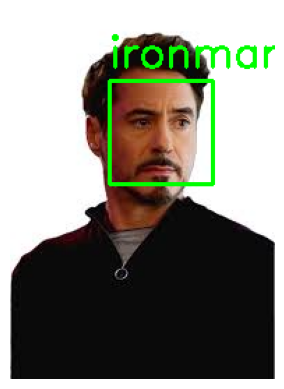

In [43]:
img = cv2.imread(r"Z:\testtony.jpg")  # put a test image in same folder
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in faces:
    face = img[y:y+h, x:x+w]

    face_resized = cv2.resize(face, (224, 224))
    face_resized = face_resized / 255.0
    face_resized = np.expand_dims(face_resized, axis=0)

    feature = feature_extractor.predict(face_resized)
    pred = clf.predict(feature)
    name = le.inverse_transform(pred)[0]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img, name, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Show result
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


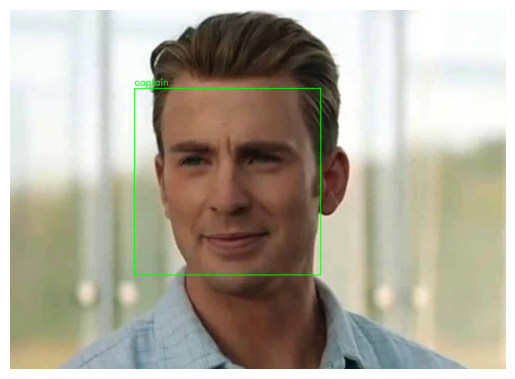

In [44]:
img = cv2.imread(r"Z:\cap3.webp")  # put a test image in same folder
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in faces:
    face = img[y:y+h, x:x+w]

    face_resized = cv2.resize(face, (224, 224))
    face_resized = face_resized / 255.0
    face_resized = np.expand_dims(face_resized, axis=0)

    feature = feature_extractor.predict(face_resized)
    pred = clf.predict(feature)
    name = le.inverse_transform(pred)[0]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img, name, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Show result
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()